In [70]:
import torch 
torch.set_default_dtype(torch.float64)
DEVICE = "cuda:1"
from matplotlib import pyplot

In [71]:
# N = 14*14 
# M = 5*1000//5*14
N = 10 
M = 15
J = torch.rand(M,N,device=DEVICE)
eyeN = torch.eye(N,device=DEVICE)
print("J.shape = %s"%str(tuple(J.shape)))
print("eyeN.shape = %s"%str(tuple(eyeN.shape)))

J.shape = (15, 10)
eyeN.shape = (10, 10)


In [99]:
Theta = J.T@J 
D,Q = torch.linalg.eigh(Theta)
Q[:,0] = -Q[:,0]
print(torch.linalg.det(Q))
assert torch.allclose((Q*D)@Q.T,Theta)
print("Theta.shape = %s"%str(tuple(Theta.shape)))
print("D.shape = %s"%str(tuple(D.shape)))
print("Q.shape = %s"%str(tuple(Q.shape)))

tensor(1.0000, device='cuda:1')
Theta.shape = (10, 10)
D.shape = (10,)
Q.shape = (10, 10)


In [100]:
torch.linalg.det(Q),torch.linalg.det(eyeN-Q)

(tensor(1.0000, device='cuda:1'), tensor(0.4858, device='cuda:1'))

In [ ]:
#C = torch.linalg.solve(eyeN+Q,eyeN-Q,left=False)
C = (eyeN-Q)@torch.linalg.inv(eyeN+Q)
print("C.shape = %s"%str(tuple(C.shape)))
print(C[:5,:5])
assert torch.allclose((eyeN-C)@torch.linalg.inv(eyeN+C),Q)

C.shape = (10, 10)
tensor([[-1.2490e-16,  6.8284e-01,  2.2617e-01,  1.8769e-01,  8.6928e-01],
        [-6.8284e-01,  2.6437e-15, -5.1870e-01,  1.6370e+00, -1.5390e+00],
        [-2.2617e-01,  5.1870e-01,  6.9389e-17,  6.3798e-01, -1.0807e+00],
        [-1.8769e-01, -1.6370e+00, -6.3798e-01, -1.2074e-15, -3.3974e-01],
        [-8.6928e-01,  1.5390e+00,  1.0807e+00,  3.3974e-01, -1.3288e-15]],
       device='cuda:1')


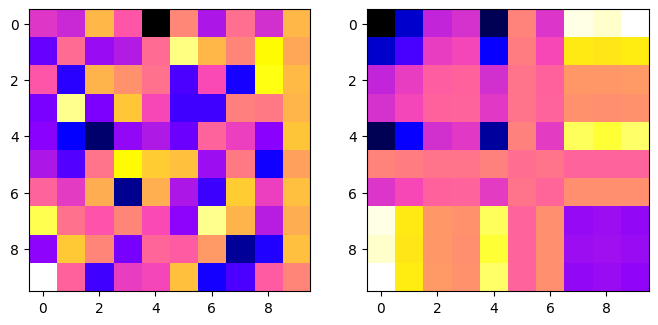

In [76]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(8,4))
ax[0].imshow(Q.cpu(),cmap="gnuplot2")
ax[1].imshow(C.cpu(),cmap="gnuplot2")

In [63]:
R = torch.rand(N,N,device=DEVICE).tril(-1)
Cr = R-R.tril(-1).T
assert (Cr==(-Cr.T)).all()
print(Cr[:5,:5])
Q = torch.linalg.solve(eyeN+Cr.T,eyeN-Cr.T).T
(Q@Q.T)[:5,:5]

tensor([[ 0.0000, -0.8217, -0.3022, -0.3124, -0.1348],
        [ 0.8217,  0.0000, -0.2667, -0.0503, -0.9754],
        [ 0.3022,  0.2667,  0.0000, -0.0871, -0.6079],
        [ 0.3124,  0.0503,  0.0871,  0.0000, -0.2717],
        [ 0.1348,  0.9754,  0.6079,  0.2717,  0.0000]], device='cuda:1')


tensor([[ 1.0000e+00, -5.5511e-17, -1.9429e-16,  2.6368e-16, -6.2450e-17],
        [-5.5511e-17,  1.0000e+00,  1.9429e-16, -1.0408e-17, -3.1225e-17],
        [-1.9429e-16,  1.9429e-16,  1.0000e+00, -1.7347e-16,  2.7756e-17],
        [ 2.6368e-16, -1.0408e-17, -1.7347e-16,  1.0000e+00,  6.0715e-17],
        [-6.2450e-17, -3.1225e-17,  2.7756e-17,  6.0715e-17,  1.0000e+00]],
       device='cuda:1')

In [64]:
evals,evecs = torch.linalg.eig(Vh)
print("evals.shape = %s"%str(tuple(evals.shape)))
print("evecs.shape = %s"%str(tuple(evecs.shape)))
assert torch.allclose((evecs*evals)@evecs.H,Vh)

evals.shape = (10,)
evecs.shape = (10, 10)


RuntimeError: ComplexDouble did not match Double